**Reconocimiento de Dígitos Manuscritos con Keras**

**1. Instalación de Dependencias**

In [17]:
!pip install tensorflow numpy matplotlib keras

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**2. Importar Librerías**

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import models, layers
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

**3. Cargar los Datos**

In [19]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [20]:
print(f'Dataset de entrenamiento: Imágenes: {x_train.shape} | Etiquetas: {y_train.shape}')
print(f'Dataset de test: Imágenes: {x_test.shape} | Etiquetas: {y_test.shape}')

Dataset de entrenamiento: Imágenes: (60000, 28, 28) | Etiquetas: (60000,)
Dataset de test: Imágenes: (10000, 28, 28) | Etiquetas: (10000,)


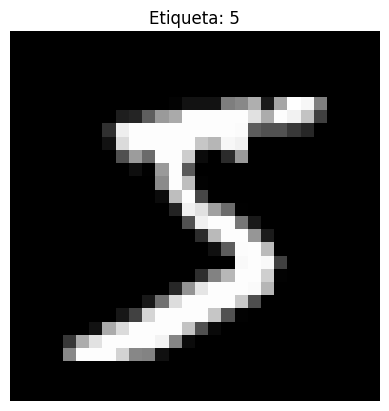

Etiqueta asociada a la imagen 0: 5


In [21]:
plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(f'Etiqueta: {y_train[0]}')
plt.axis('off')
plt.show()
print(f'Etiqueta asociada a la imagen 0: {y_train[0]}')

**4. Preprocesamiento**
4.1 Preparando las Imágenes

In [22]:
x_train = x_train.reshape(x_train.shape[0], 28 * 28).astype('float32') / 255
x_test  = x_test.reshape(x_test.shape[0],  28 * 28).astype('float32') / 255

print(f'Forma x_train tras preprocesado: {x_train.shape}')
print(f'Forma x_test  tras preprocesado: {x_test.shape}')

Forma x_train tras preprocesado: (60000, 784)
Forma x_test  tras preprocesado: (10000, 784)


4.2 Preparando las Etiquetas — One-Hot Encoding

In [23]:
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

print(f'y_train[0] (one-hot): {y_train[0]}')

y_train[0] (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


**5. Creación de la Red Neuronal**

In [24]:
modelo = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28 * 28,)),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**6. Entrenamiento**

In [26]:
history = modelo.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9173 - loss: 0.2735 - val_accuracy: 0.9579 - val_loss: 0.1241
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9672 - loss: 0.1083 - val_accuracy: 0.9731 - val_loss: 0.0839
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9768 - loss: 0.0737 - val_accuracy: 0.9753 - val_loss: 0.0761
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9810 - loss: 0.0598 - val_accuracy: 0.9769 - val_loss: 0.0711
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9839 - loss: 0.0492 - val_accuracy: 0.9797 - val_loss: 0.0682
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9868 - loss: 0.0425 - val_accuracy: 0.9815 - val_loss: 0.0644
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9885 - loss: 0.0350 - val_accuracy: 0.9816 - val_loss: 0.0658
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9891 - loss: 0.0319 - val_accuracy: 0.

**7. Evaluación**

In [ ]:
score = modelo.evaluate(x_test, y_test, verbose=0)
print(f'Modelo — Accuracy: {score[1]*100:.2f}%   Loss: {score[0]:.4f}')

Modelo — Accuracy: 98.19%   Loss: 0.0767


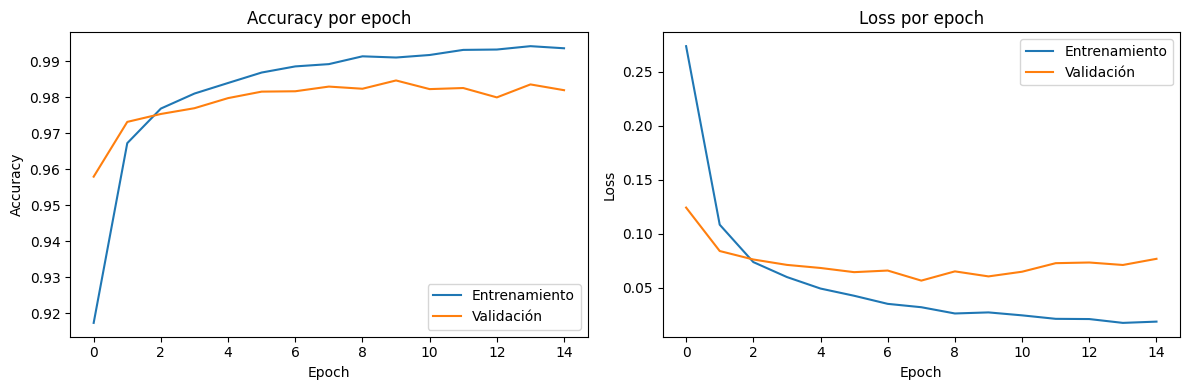

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy por epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Loss por epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

**8. Uso**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


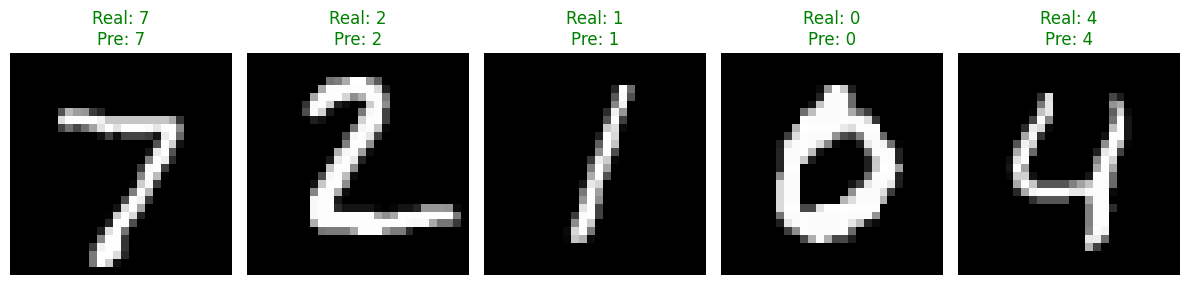

In [ ]:
predicciones = np.argmax(modelo.predict(x_test), axis=1)
etiquetasReales = np.argmax(y_test, axis=1)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicciones[i] == etiquetasReales[i] else 'red'
    ax.set_title(f'Real: {etiquetasReales[i]}\nPre: {predicciones[i]}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()
